In [2]:
import pandas as pd



df = pd.read_csv("SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (9994, 13)

Columns:
Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [4]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows: 17


In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new dataset shape
print("New Dataset Shape:", df.shape)

New Dataset Shape: (9977, 13)


In [6]:
# Basic statistics
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [7]:
# Top 10 States by Sales

top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

top_states.head(10)

,Sales
State,
California,457576.2715
New York,310827.1510
Texas,170124.5418
Washington,138560.8100
Pennsylvania,116496.3620
Florida,89473.7080
Illinois,80162.5370
Ohio,77976.7640
Michigan,75879.6440


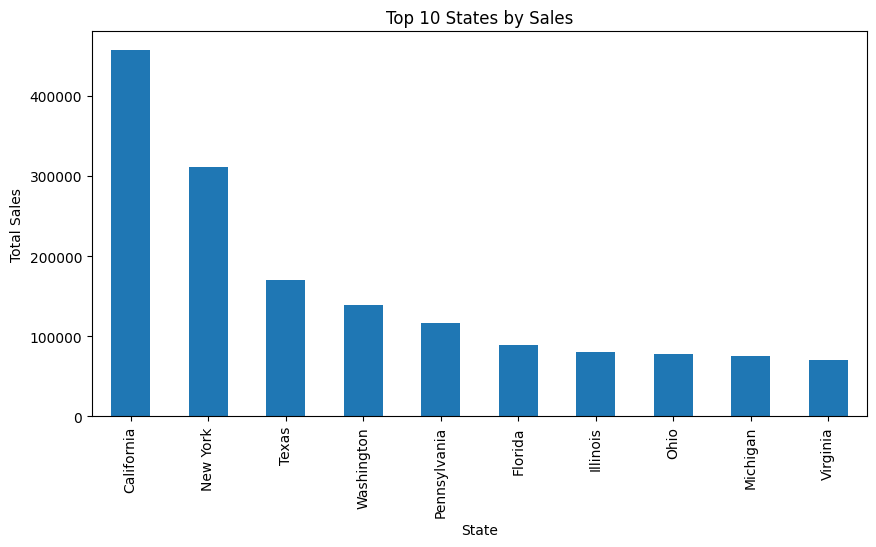

In [27]:
import matplotlib.pyplot as plt

top_states.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.savefig("Top_10_States_by_Sales.png", dpi=300, bbox_inches="tight")
plt.show()

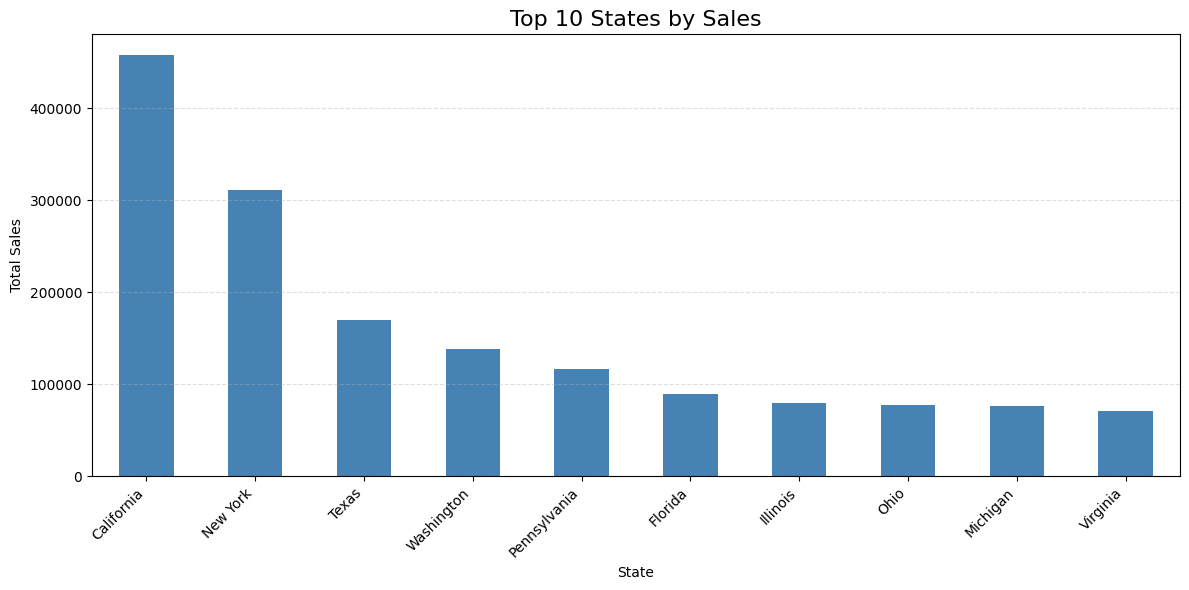

In [9]:
import matplotlib.pyplot as plt

top_states.head(10).plot(
    kind="bar",
    figsize=(12,6),
    color="steelblue"
)

plt.title("Top 10 States by Sales", fontsize=16)
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [11]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741306.3133
Office Supplies,718735.2440


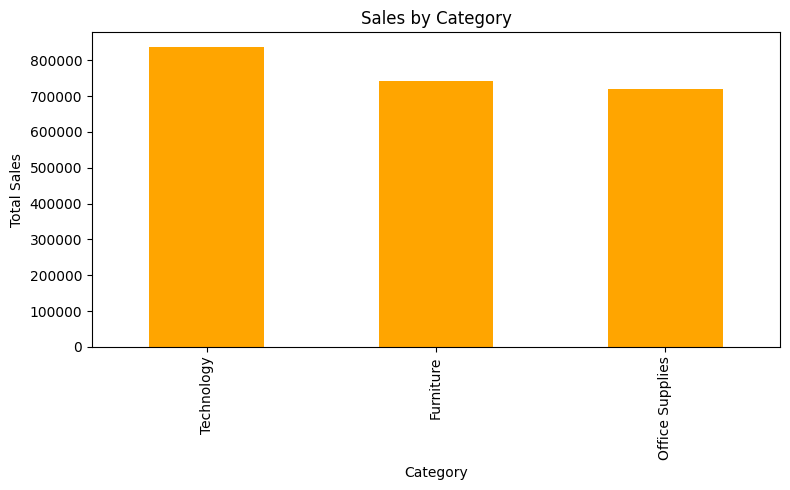

In [12]:
category_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="orange"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [14]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales.head(10)

,Sales
Sub-Category,
Phones,330007.0540
Chairs,327777.7610
Storage,223843.6080
Tables,206965.5320
Binders,203409.1690
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


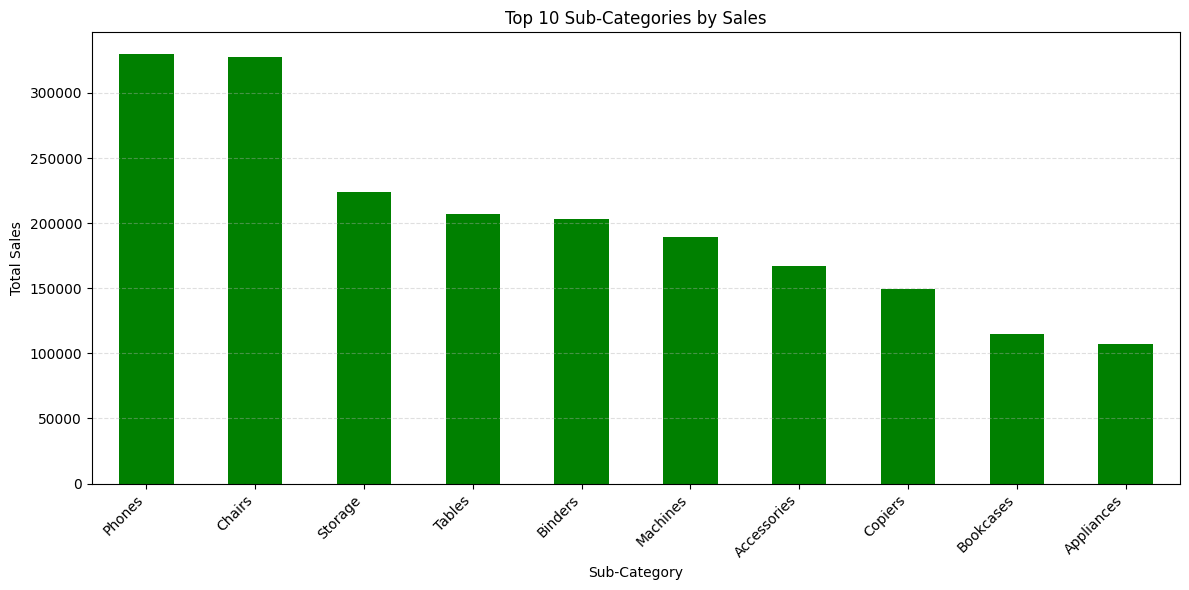

In [15]:
import matplotlib.pyplot as plt

subcategory_sales.head(10).plot(
    kind="bar",
    figsize=(12,6),
    color="green"
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:
profit_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

profit_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122364.6608
Furniture,18421.8137


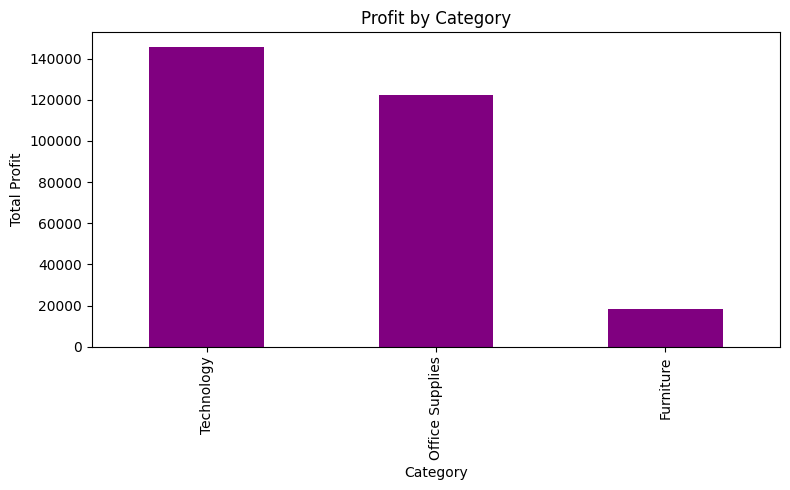

In [18]:
import matplotlib.pyplot as plt

profit_category.plot(
    kind="bar",
    figsize=(8,5),
    color="purple"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

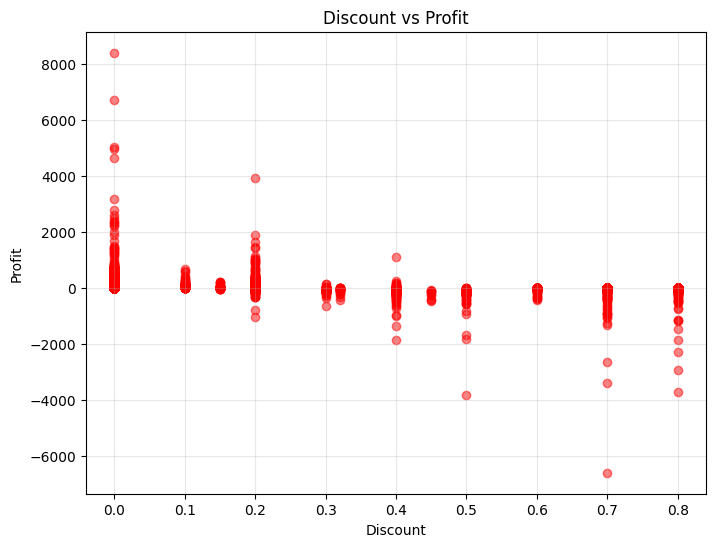

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5,
    color="red"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

In [20]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725255.6365
East,678435.1960
Central,500782.8528
South,391721.9050


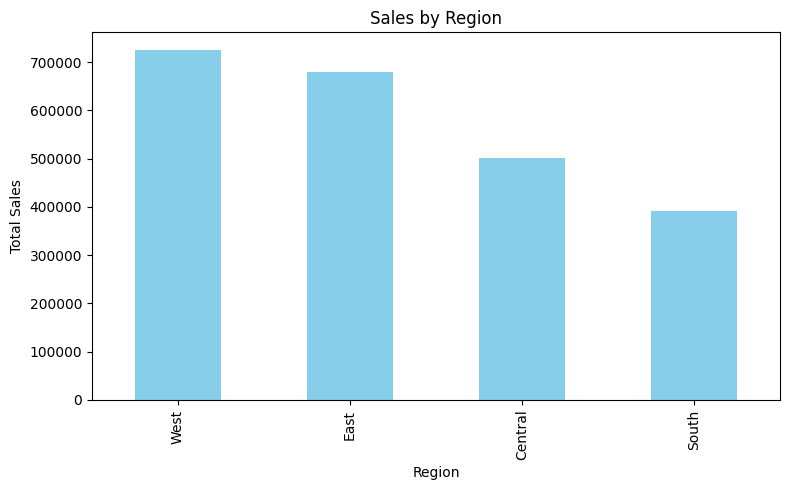

In [21]:
region_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

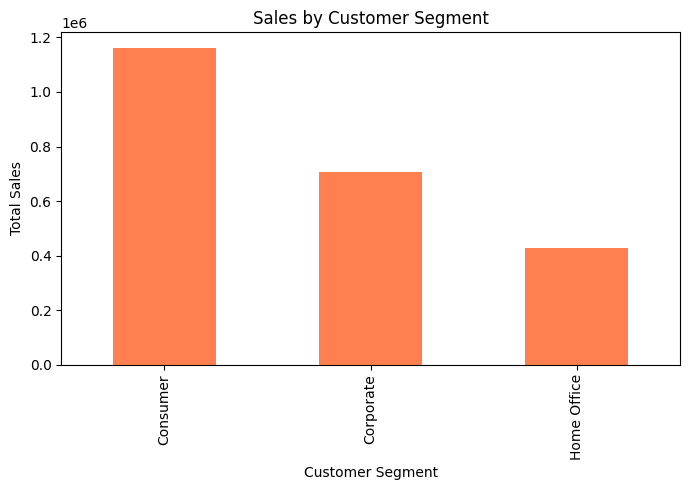

In [22]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales.plot(
    kind="bar",
    figsize=(7,5),
    color="coral"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## Key Findings

1. California generated the highest sales among all states.

2. Technology was the highest revenue-generating category.

3. Furniture generated the lowest profit despite strong sales.

4. Consumer customers contributed the largest share of total sales.

5. Higher discounts were often associated with lower profits.

6. The West region achieved the highest overall sales performance.

# Business Recommendations

## Recommendations

- Increase investment in Technology products.
- Review discount strategies to protect profit margins.
- Improve Furniture profitability by optimizing pricing and costs.
- Focus marketing campaigns on Consumer customers.
- Expand successful sales strategies from the West region to other regions.

In [28]:
import os

os.makedirs("images", exist_ok=True)

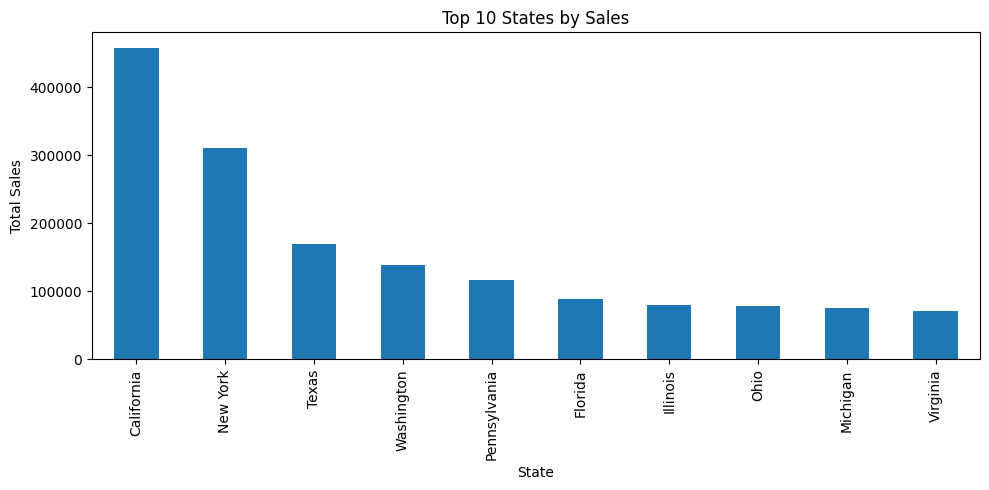

In [33]:
import matplotlib.pyplot as plt

top_states.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("images/Top_10_States_by_Sales.png", dpi=300)

plt.show()

In [32]:
import os

os.makedirs("images", exist_ok=True)

In [34]:
import os
print(os.listdir("images"))

['Top_10_States_by_Sales.png']


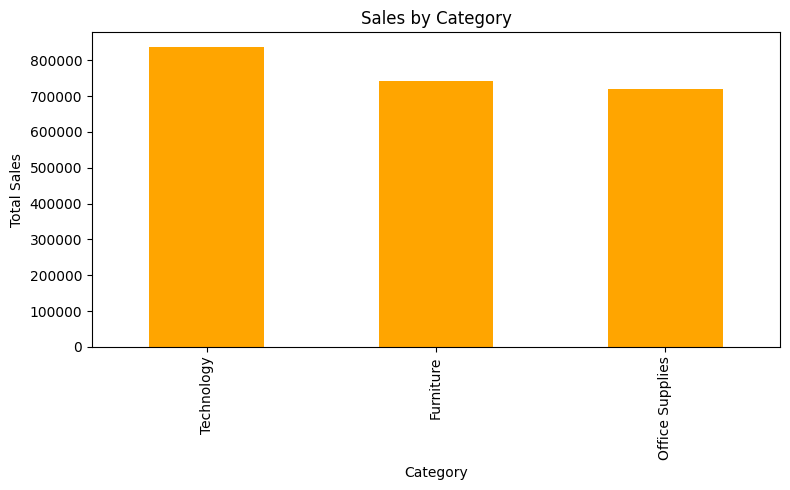

In [35]:
# Sales by Category

import matplotlib.pyplot as plt

category_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="orange"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("images/Sales_by_Category.png", dpi=300)
plt.show()

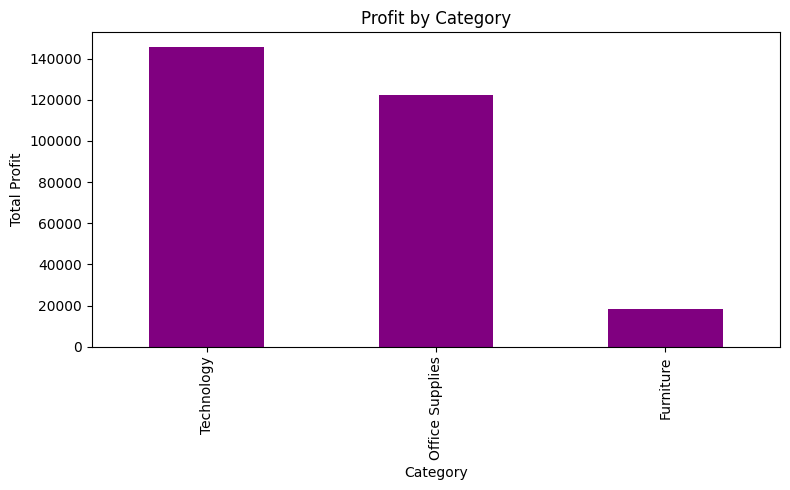

In [36]:
# Profit by Category

import matplotlib.pyplot as plt

profit_category.plot(
    kind="bar",
    figsize=(8,5),
    color="purple"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.savefig("images/Profit_by_Category.png", dpi=300)
plt.show()

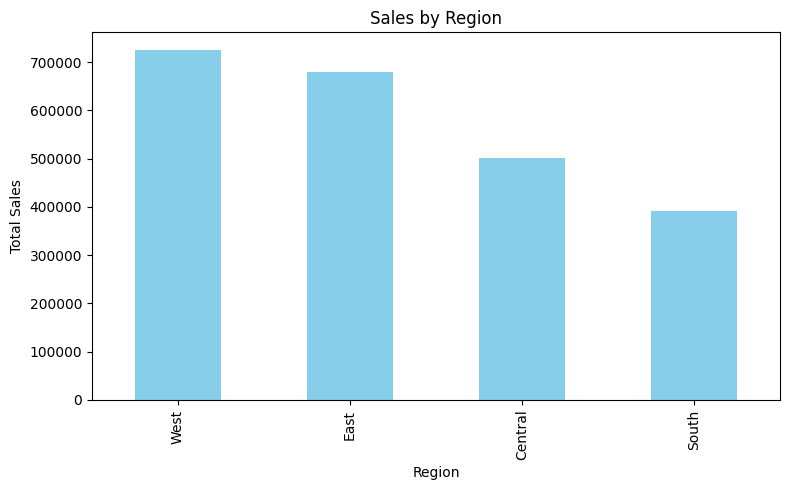

In [37]:
# Sales by Region

import matplotlib.pyplot as plt

region_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("images/Sales_by_Region.png", dpi=300)
plt.show()

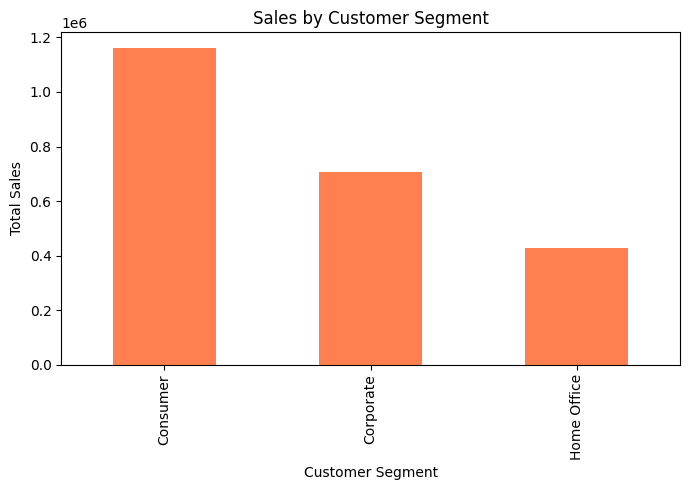

In [38]:
# Sales by Customer Segment

import matplotlib.pyplot as plt

segment_sales.plot(
    kind="bar",
    figsize=(7,5),
    color="coral"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("images/Sales_by_Customer_Segment.png", dpi=300)
plt.show()

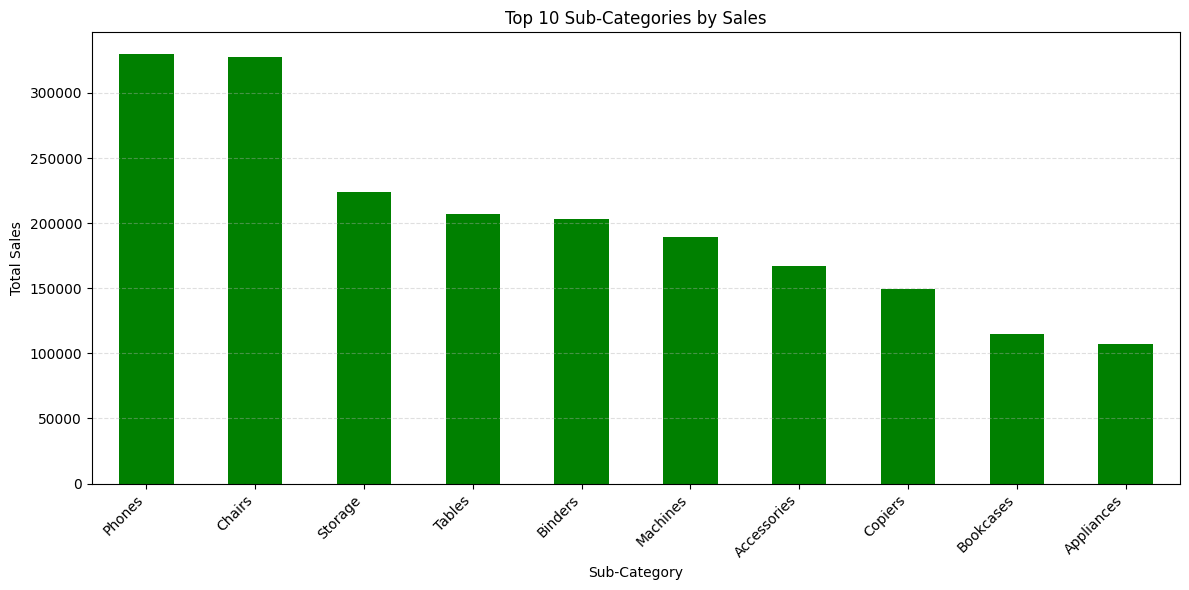

In [39]:
# Top 10 Sub-Categories

import matplotlib.pyplot as plt

subcategory_sales.head(10).plot(
    kind="bar",
    figsize=(12,6),
    color="green"
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("images/Top_10_Subcategories.png", dpi=300)
plt.show()

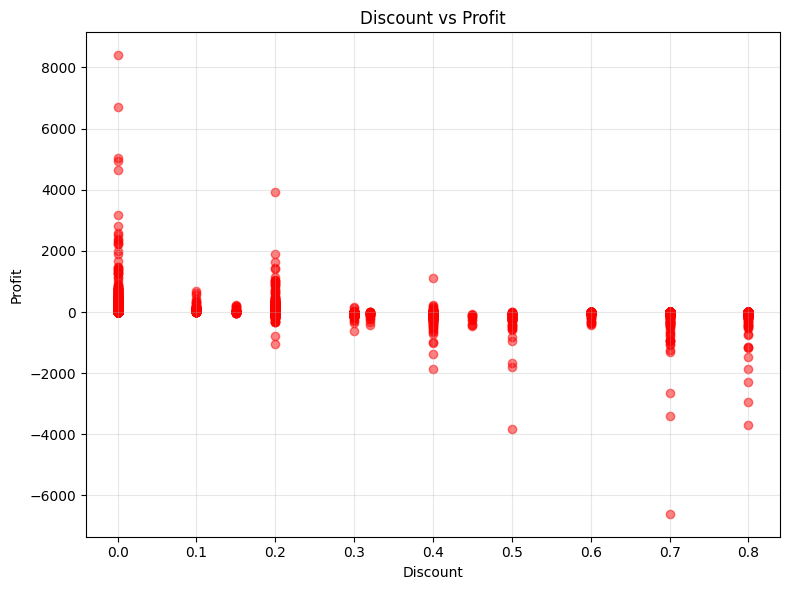

In [40]:
# Discount vs Profit

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5,
    color="red"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("images/Discount_vs_Profit.png", dpi=300)
plt.show()

In [42]:
import os

print(os.listdir("images"))

['Sales_by_Customer_Segment.png', 'Sales_by_Region.png', 'Profit_by_Category.png', 'Discount_vs_Profit.png', 'Top_10_States_by_Sales.png', 'Sales_by_Category.png', 'Top_10_Subcategories.png']
